In [1]:
import matplotlib.pyplot as plt
import numpy as np
from csv import reader
from math import sqrt, log, sin, pi, cos
from random import sample
from scipy.optimize import brentq
from scipy.optimize import minimize

selection_main: list = []

with open('var_8_loglaplace.csv', mode ='r')as file:
    csvFile = reader(file)
    for lines in csvFile:
        selection_main.append(float(lines[0]))

Сумма элементов выборки:

In [2]:
def my_sum(selection: list) -> float:
    summa: int = 0
    for elem in selection:
        summa += elem
    return round(summa, 2)

In [3]:
my_sum(selection_main)

-667.93

Выборочное среднее:

In [4]:
def mid(selection: list) -> float:
    selection_len: int = len(selection)
    summa: int = my_sum(selection)
    return round(summa / selection_len, 2)

In [5]:
mid(selection_main)

-2.23

Медиана:

In [6]:
def median(selection: list) -> float:
    selection_len: int = len(selection)
    sorted_selection: list = sorted(selection)
    if selection_len % 2 == 0:
        half: int = int(selection_len / 2)
        return round((sorted_selection[half] + sorted_selection[half + 1]) / 2, 2)
    else:
        return round(sorted_selection[half], 2)

In [7]:
median(selection_main)

-2.27

Мода:

In [8]:
def moda(selection: list) -> float:
    freq_dict = {}
    for elem in selection:
        freq_dict[elem] = freq_dict.get(elem, 0) + 1
        
    max_freq: int = max(freq_dict.values())

    if(max_freq == 1):
        return None
    
    for key, value in freq_dict.items():
        if value == max_freq:
            return key

In [9]:
print(moda(selection_main))

None


Размах выборки:

In [10]:
def razmah(selection: list) -> float:
    return round(max(selection) - min(selection), 2)

In [11]:
razmah(selection_main)

2.24

Смещенная дисперсия:

In [12]:
def smesh_dispersion(selection: list) -> float:
    selection_len: int = len(selection)
    mid_val: float = mid(selection)
    summa: float = 0
    for elem in selection:
        summa += (mid_val - elem) ** 2
    return round(summa / selection_len, 2)

In [13]:
smesh_dispersion(selection_main)

0.11

Несмещенная дисперсия:

In [14]:
def nesmesh_dispersion(selection: list) -> float:
    selection_len: int = len(selection)
    mid_val: float = mid(selection)
    summa: float = 0
    for elem in selection:
        summa += (mid_val - elem) ** 2
    return round(summa / (selection_len - 1), 2)

In [15]:
nesmesh_dispersion(selection_main)

0.11

Выборочный начальный элемент:

In [16]:
def choose_first_elem(selection: list, k: int) -> float:
    selection_len: int = len(selection)
    summa: float = 0
    for elem in selection:
        summa += elem ** k
    return round(summa / selection_len, 2)

In [17]:
choose_first_elem(selection_main, 3)

-11.75

Выборочный центральный элемент:

In [18]:
def choose_center_elem(selection: list, k: int) -> float:
    selection_len: int = len(selection)
    mid_val: float = mid(selection)
    summa: float = 0
    for elem in selection:
        summa += (mid_val - elem) ** k
    return round(sqrt(summa / selection_len), 2)

In [19]:
choose_center_elem(selection_main, 6)

0.31

Эмперическая функция распределения:

In [20]:
def ecdf(selection: list, count: int):
    sorted_selection = sorted(selection)

    x = []
    y = []

    for i in range(count):
        x.append(sorted_selection[i])
        y.append((i + 1) / count)

    return x, y

График эмперической функции:

In [21]:
def show_graphic_ecdf(x: list, y: list, count: int = -1):
    plt.figure()
    plt.step(x, y, where='post', label="Эмперическая функция")
    plt.scatter(x, y, label="Точки выборки")
    
    plt.xlabel('x')
    plt.ylabel('F*(x)')
    if(count == -1):
        plt.title(f'Эмперическая функция распределения')
    else:
        plt.title(f'Эмперическая функция распределения для выборки из {count} элементов')
    plt.legend()
    plt.grid()
    
    plt.show()

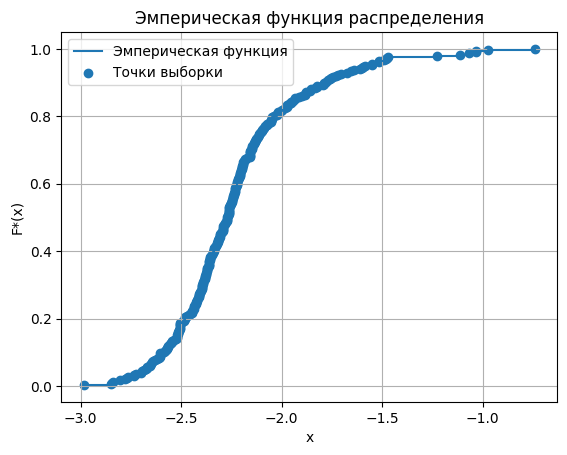

In [22]:
selection_len: int = len(selection_main)
x, y = ecdf(selection_main, selection_len)
show_graphic_ecdf(x, y)

График эмперичиской функции для 10 случайных элементов:

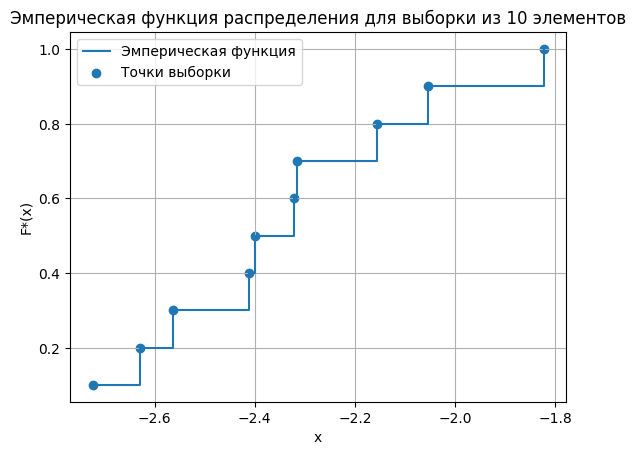

In [23]:
selection_10 = sample(selection_main, 10)
x, y = ecdf(selection_10, 10)
show_graphic_ecdf(x, y, 10)

График эмперической функции для 100 случайных элементов:

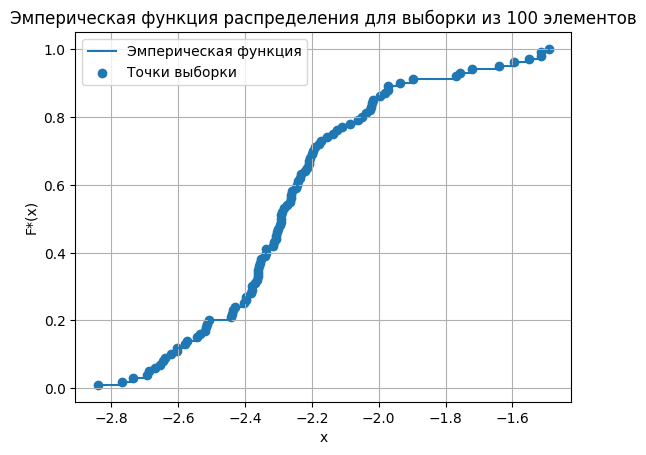

In [24]:
selection_100 = sample(selection_main, 100)
x, y = ecdf(selection_100, 100)
show_graphic_ecdf(x, y, 100)

График эмперичиской функции для 200 случайных элементов:

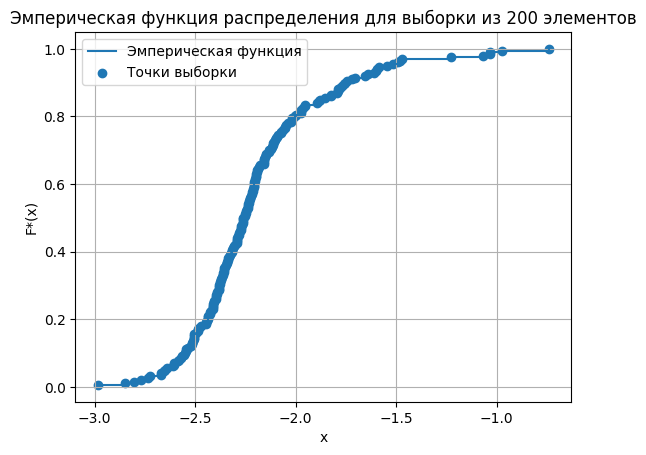

In [25]:
selection_200 = sample(selection_main, 200)
x, y = ecdf(selection_200, 200)
show_graphic_ecdf(x, y, 200)

In [26]:
def histogram(selection: list, bins=10):
    min_val = min(selection)
    max_val = max(selection)

    bin_width: float = (max_val - min_val) / bins

    edges = [min_val + i * bin_width for i in range(bins + 1)]

    counts = [0] * bins

    for elem in selection:
        for i in range(bins):
            if(edges[i] <= elem < edges[i+1]):
                counts[i] += 1
                break
        else:
            counts[-1] += 1

    return edges, counts

Гистограмма:

In [27]:
def show_histogram(edges: list, counts: list, vyborka: int = -1):
    centers = [(edges[i] + edges[i+1]) / 2 for i in range(len(edges)-1)]
    
    plt.figure()
    
    plt.bar(centers, counts, width=(edges[1] - edges[0]), alpha=0.6, label="Гистограмма")
    
    plt.plot(centers, counts, marker='o', label="График частот"),

    if(vyborka == -1):
        plt.title("Гистограмма")
    else:
        plt.title(f"Гистограмма для выборки из {vyborka} элементов")
    
    plt.xlabel("Значения")
    plt.ylabel("Частота")
    plt.legend()
    plt.grid()
    
    plt.show()

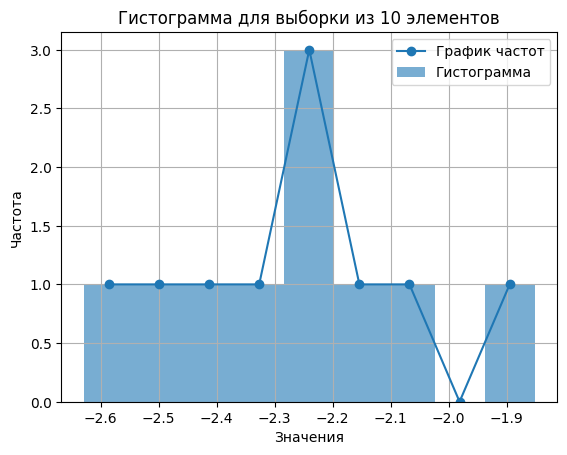

In [28]:
selection_10 = sample(selection_main, 10)
selection_len: int = len(selection_main)
bins_count: int = 1 + int(log(selection_len, 2))
edges, counts = histogram(selection_10, bins_count)
show_histogram(edges, counts, 10)

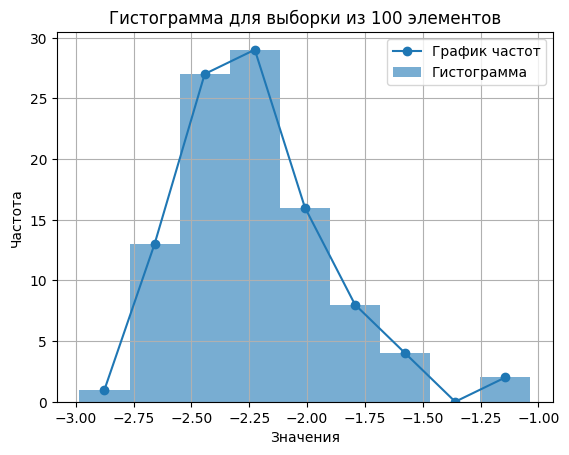

In [29]:
selection_100 = sample(selection_main, 100)
edges, counts = histogram(selection_100, bins_count)
show_histogram(edges, counts, 100)

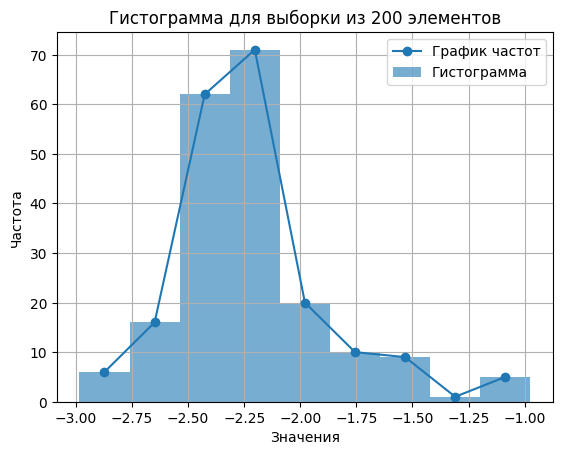

In [30]:
selection_200 = sample(selection_main, 200)
edges, counts = histogram(selection_200, bins_count)
show_histogram(edges, counts, 200)

Параметры loc и a по методу моментов:

In [31]:
def theoretical_mean_no_loc(c):
    """E[X] без сдвига, требует c > 1"""
    return c**2 / (c**2 - 1)

def theoretical_variance(c):
    """D[X] не зависит от loc, требует c > 2"""
    ex  = c**2 / (c**2 - 1)
    ex2 = c**2 / (c**2 - 4)
    return ex2 - ex**2


# ── Метод моментов ───────────────────────────────────────────────────────────

def find_loc_a_moment(selection):
    """
    Система уравнений метода моментов:
    
      (1)  s² = D[X](c)          -> находим c
      (2)  x̄  = E[X](c) + loc   -> находим loc = x̄ - E[X](c)
    
    Возвращает (c_hat, loc_hat)
    """
    x_bar = mid(selection)
    s2    = smesh_dispersion(selection)

    # Шаг 1: решаем D[X](c) = s² относительно c
    # D[X](c) убывает по c, при c->2+ уходит в +inf, при c->inf -> 0
    def equation(c):
        return theoretical_variance(c) - s2

    c_hat = brentq(equation, 2.001, 10000.0, xtol=1e-12)

    # Шаг 2: loc = x̄ - E[X](c)
    loc_hat = x_bar - theoretical_mean_no_loc(c_hat)

    return round(c_hat, 2), round(loc_hat, 2)

In [32]:
find_loc_a_moment(selection_main)

(4.92, -3.27)

Параметры loc и a по методу максимального правдоподобия:

In [33]:
class Point:
    def __init__(self, a: float = 0, loc: float = 0):
        self.a = a
        self.loc = loc

    def get_dist(self, other):
        return sqrt((self.a - other.a) ** 2 + (self.loc - other.loc) ** 2)

    a: float
    loc: float


def find_mid(a: Point, b: Point) -> Point:
    return Point((a.a + b.a) / 2, (a.loc + b.loc) / 2)


def find_new(a: Point, b: Point, c: Point) -> Point:
    mid_point: Point = find_mid(a, b)
    return Point(2 * mid_point.a - c.a, 2 * mid_point.loc - c.loc)


def func_pravdopodobie(selection: list, p: Point) -> float:
    sum_val: float = 0
    for elem in selection:
        fxi: float = 0
        if elem - p.loc <= 0:
            return float("-inf")
        elif elem - p.loc <= 1:
            fxi = log(p.a / 2) + (p.a - 1) * log(elem - p.loc)
        else:
            fxi = log(p.a / 2) - (p.a + 1) * log(elem - p.loc)

        sum_val += fxi

    return sum_val


def find_loc_a_max_prav(selection: list) -> list:
    a, loc = find_loc_a_moment(selection)
    point_1 = Point(a, loc + 0.1)
    point_2 = Point(a, loc)
    point_3 = Point(a + 1, loc)

    for _ in range(100000):
        fp1 = func_pravdopodobie(selection, point_1)
        fp2 = func_pravdopodobie(selection, point_2)
        fp3 = func_pravdopodobie(selection, point_3)

        # Условие остановки
        if (point_1.get_dist(point_2) < 0.00001
            and point_2.get_dist(point_3) < 0.00001
            and point_1.get_dist(point_3) < 0.00001):
            break

        # Находим худшую точку
        min_fp = min(fp1, fp2, fp3)

        if min_fp == fp1:
            worst, p2, p3, fw, f2, f3 = point_1, point_2, point_3, fp1, fp2, fp3
        elif min_fp == fp2:
            worst, p2, p3, fw, f2, f3 = point_2, point_1, point_3, fp2, fp1, fp3
        else:
            worst, p2, p3, fw, f2, f3 = point_3, point_1, point_2, fp3, fp1, fp2

        # Отражаем худшую через середину противоположного ребра
        new_point = find_new(p2, p3, worst)
        fp_new = func_pravdopodobie(selection, new_point)

        if fp_new > fw:
            # Отражение улучшило — заменяем худшую
            if min_fp == fp1:
                point_1 = new_point
            elif min_fp == fp2:
                point_2 = new_point
            else:
                point_3 = new_point
        else:
            # Отражение не помогло — сжимаем к лучшей
            max_fp = max(fp1, fp2, fp3)
            if max_fp == fp1:
                best = point_1
            elif max_fp == fp2:
                best = point_2
            else:
                best = point_3

            point_1 = find_mid(best, point_1)
            point_2 = find_mid(best, point_2)
            point_3 = find_mid(best, point_3)

    fp1 = func_pravdopodobie(selection, point_1)
    fp2 = func_pravdopodobie(selection, point_2)
    fp3 = func_pravdopodobie(selection, point_3)
    max_fp = max(fp1, fp2, fp3)
    if max_fp == fp1:
        return [round(point_1.a, 2), round(point_1.loc, 2)]
    elif max_fp == fp2:
        return [round(point_2.a, 2), round(point_2.loc, 2)]
    else:
        return [round(point_3.a, 2), round(point_3.loc, 2)]


In [34]:
find_loc_a_max_prav(selection_main)

[4.33, -3.27]

Свойства оценок:

In [35]:
def generate_loglaplace(a, loc, size):
    u = np.random.uniform(0, 1, size)
    x = np.where(
        u <= 0.5,
        loc + (2 * u) ** (1 / a),
        loc + (2 * (1 - u)) ** (-1 / a)
    )
    return x

a_true, loc_true = find_loc_a_max_prav(selection_main)
n = 300
def unbiasedness():
    mm_a_vals = []
    mle_a_vals = []
    mm_loc_vals = []
    mle_loc_vals = []
    for i in range(1000):
        sample = generate_loglaplace(a_true, loc_true, n)
    
        a_mm, loc_mm = find_loc_a_moment(sample)
        a_mle, loc_mle = find_loc_a_max_prav(sample)
        mm_a_vals.append(a_mm)
        mle_a_vals.append(a_mle)
        mm_loc_vals.append(loc_mm)
        mle_loc_vals.append(loc_mle)
        
    mm_a = np.array(mm_a_vals)
    mle_a = np.array(mle_a_vals)
    mm_loc = np.array(mm_loc_vals)
    mle_loc = np.array(mle_loc_vals)
    
    print("=== Несмещённость ===")
    print(f"ММ:  E[a] = {mm_a.mean():.2f},  смещение = {mm_a.mean() - a_true:+.2f}")
    print(f"ММП:  E[a] = {mle_a.mean():.2f},  смещение = {mle_a.mean() - a_true:+.2f}")
    print(f"ММ:  E[loc] = {mm_loc.mean():.2f},  смещение = {mm_loc.mean() - loc_true:+.2f}")
    print(f"ММП:  E[loc] = {mle_loc.mean():.2f},  смещение = {mle_loc.mean() - loc_true:+.2f}")

def consistensy():
    print("\n=== Состоятельность (разброс при разных n) ===")
    for size in [50, 100, 200, 300, 500]:
        tmp_mm, tmp_mle = [], []
        for i in range(1000):
            sample = generate_loglaplace(a_true, loc_true, size)
            a_mm, loc_mm = find_loc_a_moment(sample)
            a_mle, loc_mle = find_loc_a_max_prav(sample)
            tmp_mm.append(a_mm)
            tmp_mle.append(a_mle)
        print(f"n={size}: ММ разброс={np.std(tmp_mm):.2f}  ММП разброс={np.std(tmp_mle):.2f}")
        
def effeciency():
    mm_a_vals = []
    mle_a_vals = []
    mm_loc_vals = []
    mle_loc_vals = []
    for i in range(1000):
        sample = generate_loglaplace(a_true, loc_true, n)
    
        a_mm, loc_mm = find_loc_a_moment(sample)
        a_mle, loc_mle = find_loc_a_max_prav(sample)
        mm_a_vals.append(a_mm)
        mle_a_vals.append(a_mle)
        mm_loc_vals.append(loc_mm)
        mle_loc_vals.append(loc_mle)
        
    mm_a = np.array(mm_a_vals)
    mle_a = np.array(mle_a_vals)
    mm_loc = np.array(mm_loc_vals)
    mle_loc = np.array(mle_loc_vals)
    
    cr_bound = a_true**2 / n
    d_mm = nesmesh_dispersion(mm_a)
    d_mle = nesmesh_dispersion(mle_a)
    
    print("\n=== Эффективность ===")
    print(f"Граница Крамера-Рао: {cr_bound:.2f}")
    print(f"ММ:  D(a) = {d_mm:.2f},  R-эфф = {cr_bound / d_mm:.2f}")
    print(f"ММП:  D(a) = {d_mle:.2f},  R-эфф = {cr_bound / d_mle:.2f}")


In [36]:
unbiasedness()
consistensy()
effeciency()

=== Несмещённость ===
ММ:  E[a] = 4.49,  смещение = +0.16
ММП:  E[a] = 4.36,  смещение = +0.03
ММ:  E[loc] = -3.27,  смещение = +0.00
ММП:  E[loc] = -3.27,  смещение = +0.00

=== Состоятельность (разброс при разных n) ===
n=50: ММ разброс=0.90  ММП разброс=0.68
n=100: ММ разброс=0.69  ММП разброс=0.47
n=200: ММ разброс=0.52  ММП разброс=0.33
n=300: ММ разброс=0.44  ММП разброс=0.27
n=500: ММ разброс=0.38  ММП разброс=0.20

=== Эффективность ===
Граница Крамера-Рао: 0.06
ММ:  D(a) = 0.20,  R-эфф = 0.31
ММП:  D(a) = 0.06,  R-эфф = 1.04


График теоретической функции распределения:

In [37]:
def teoretic(selection: list, loc: float, a: float) -> list:
    x = []
    y = []

    sorted_selection = sorted(selection)
    
    for elem in sorted_selection:
        x.append(elem)
        if(loc < elem <= loc + 1):
            y.append(0.5 * (elem - loc)**a)
        elif(elem > loc + 1):
            y.append(1 - 0.5 * (elem - loc)**(-a))

    return x, y

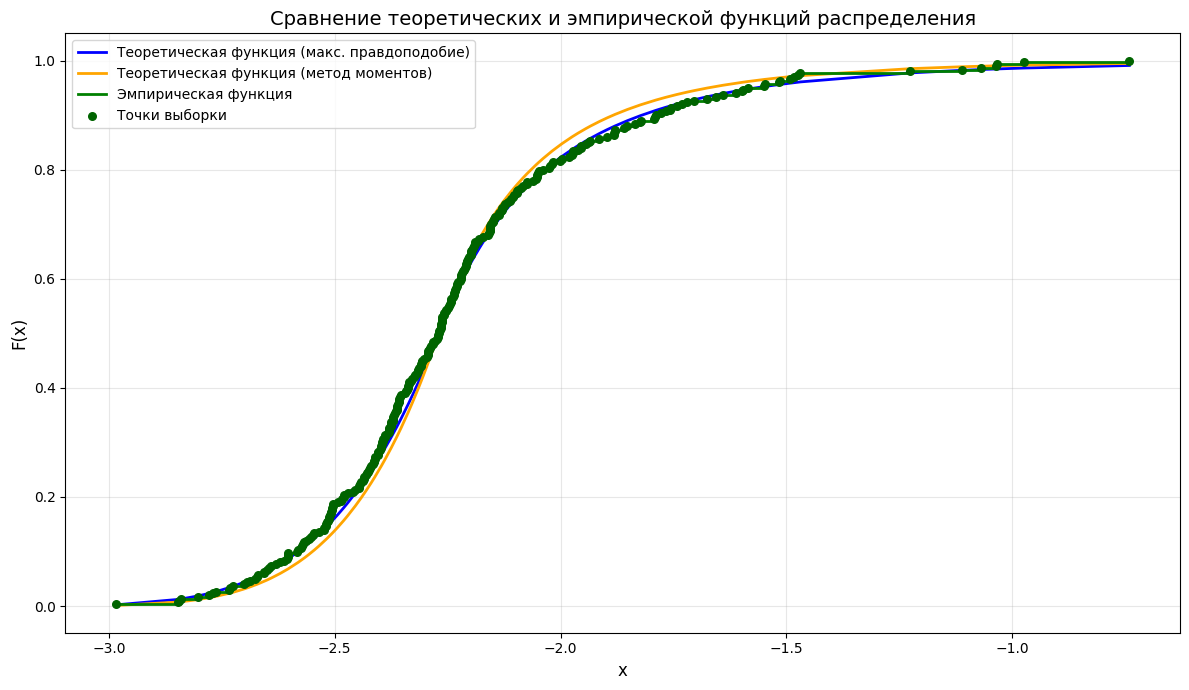

In [38]:
a, loc = find_loc_a_max_prav(selection_main)
a_2, loc_2 = find_loc_a_moment(selection_main)

x, y = teoretic(selection_main, loc, a)
x_2, y_2 = teoretic(selection_main, loc_2, a_2)

# Получаем эмпирическую функцию распределения
x_3, y_3 = ecdf(selection_main, selection_len)

# Создаем один график с тремя линиями
plt.figure(figsize=(12, 7))

# Теоретические функции
plt.plot(x, y, label="Теоретическая функция (макс. правдоподобие)", linewidth=2, color='blue')
plt.plot(x_2, y_2, label="Теоретическая функция (метод моментов)", linewidth=2, color='orange')

# Эмпирическая функция (ступенчатая)
plt.step(x_3, y_3, where='post', label="Эмпирическая функция", linewidth=2, color='green')

# Точки выборки
plt.scatter(x_3, y_3, label="Точки выборки", color='darkgreen', s=30, zorder=5)

plt.xlabel('x', fontsize=12)
plt.ylabel('F(x)', fontsize=12)
plt.title('Сравнение теоретических и эмпирической функций распределения', fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Мера разброса оценки:

In [39]:
def se_a(a: float, n: float) -> float:
    return 1 / sqrt(n / a**2)

def se_loc(selection: list, loc: float, a: float) -> float:
    sum_min: float = 0
    sum_max: float = 0
    
    for elem in selection:
        if(elem - loc <= 1):
            sum_min += (1 - a) / (elem - loc)**2
        else:
            sum_max -= (a + 1) / (elem - loc)**2
    
    return 1 / sqrt(-(sum_min + sum_max))

def mera_spread(selection: list, a: float, loc: float, n: float, z: float) -> list:
    return [[round(a - z * se_a(a, n), 2), round(a + z * se_a(a, n), 2)], [round(loc - z * se_loc(selection, loc, a), 2), round(loc + z * se_loc(selection, loc, a), 2)]]

In [40]:
a, loc = find_loc_a_max_prav(selection_main)

z: float = 1.96
print(mera_spread(selection_main, a, loc, selection_len, z))
z: float = 2.576
print(mera_spread(selection_main, a, loc, selection_len, z))

[[3.84, 4.82], [-3.32, -3.22]]
[[3.69, 4.97], [-3.34, -3.2]]


Ошибки первого и второго рода:

In [44]:
def generate_loglaplace_sample(a: float, loc: float, n=1000):
    """Генерация выборки из log-Laplace через обратную функцию распределения (inverse transform sampling)."""
    u = np.random.rand(n)
    x = np.where(
        u < 0.5,
        (2 * u) ** (1 / a),
        (2 * (1 - u)) ** (-1 / a)
    )
    return loc + x

def MLE(sample, n_starts=5):
    """
    Оценка максимального правдоподобия (ММП) для (a, loc).
    Многостарт: пробуем несколько начальных точек, берём лучший результат,
    чтобы избежать попадания в локальный максимум.
    """
    y_min = min(sample)
    eps = 1e-6

    def neg_ll(params):
        a, loc = params
        if a <= 0.3 or loc >= y_min - eps:
            return 1e100
        return -func_pravdopodobie(sample, Point(a, loc))

    best_res = None
    a0_candidates = [0.5, 1.0, 2.0, 3.0, 5.0]
    for a0 in a0_candidates[:n_starts]:
        x0 = [a0, y_min - 0.1]
        res = minimize(neg_ll, x0=x0, bounds=[(0.3, None), (None, y_min - eps)])
        if best_res is None or res.fun < best_res.fun:
            best_res = res

    return best_res.x[0], best_res.x[1]

def lrt_test(sample, a0, loc0):
    """
    Статистика отношения правдоподобий (Likelihood Ratio Test):
    stat = 2 * (logL(MLE) - logL(H0))
    """
    a_hat, loc_hat = MLE(sample)
    ll1 = func_pravdopodobie(sample, Point(a_hat, loc_hat))
    ll0 = func_pravdopodobie(sample, Point(a0, loc0))
    return 2 * (ll1 - ll0)

def critical_value(a0, loc0, n=300, m=1000, q=0.95):
    """
    Калибровка критического значения методом Монте-Карло:
    многократно генерируем выборки ИЗ H0 (a0, loc0), считаем статистику LRT,
    берём q-квантиль эмпирического распределения как порог c.
    Это аналог bootstrap/permutation-калибровки теста, когда
    асимптотика chi-squared не гарантирована (параметр сдвига loc
    нарушает условия регулярности).
    """
    stats = np.empty(m)
    for i in range(m):
        sample = generate_loglaplace_sample(a0, loc0, n)
        stats[i] = lrt_test(sample, a0, loc0)
    return np.quantile(stats, q)

def estimate_alpha(a0, loc0, c, n=300, m=1000):
    """
    Оценка ошибки первого рода: P(отклонить H0 | H0 верна).
    Генерируем выборки ИЗ H0 и считаем долю случаев stat > c.
    """
    count = 0
    for _ in range(m):
        sample = generate_loglaplace_sample(a0, loc0, n)
        stat = lrt_test(sample, a0, loc0)
        if stat > c:
            count += 1
    return count / m

def estimate_beta(a0, loc0, a1, loc1, c, n=300, m=1000):
    """
    Оценка ошибки второго рода: P(не отклонить H0 | верна H1).
    Генерируем выборки ИЗ H1 (a1, loc1) и считаем долю случаев stat <= c.
    """
    count = 0
    for _ in range(m):
        sample = generate_loglaplace_sample(a1, loc1, n)
        stat = lrt_test(sample, a0, loc0)
        if stat <= c:
            count += 1
    return count / m

def lrt_test_loc(sample, loc0):
    """
    LRT для проверки

        H0: loc = loc0
        H1: loc != loc0

    Параметр a в H0 оценивается методом максимального правдоподобия.
    """

    # Полная ММП
    a_hat, loc_hat = MLE(sample, n_starts=1)
    ll1 = func_pravdopodobie(sample, Point(a_hat, loc_hat))

    y_min = min(sample)
    eps = 1e-6

    # Максимизация только по a при фиксированном loc
    def neg_ll(a):
        if a[0] <= 0.3 or loc0 >= y_min - eps:
            return 1e100
        return -func_pravdopodobie(sample, Point(a[0], loc0))

    res = minimize(
        neg_ll,
        x0=[1.0],
        bounds=[(0.3, None)]
    )

    a0_hat = res.x[0]
    ll0 = func_pravdopodobie(sample, Point(a0_hat, loc0))

    return 2 * (ll1 - ll0)

def critical_value_loc(a_true, loc0, n=300, m=1000, q=0.95):
    stats = np.empty(m)

    for i in range(m):
        sample = generate_loglaplace_sample(a_true, loc0, n)
        stats[i] = lrt_test_loc(sample, loc0)

    return np.quantile(stats, q)

def estimate_alpha_loc(a_true, loc0, c, n=300, m=1000):
    count = 0

    for _ in range(m):
        sample = generate_loglaplace_sample(a_true, loc0, n)

        if lrt_test_loc(sample, loc0) > c:
            count += 1

    return count / m

def estimate_beta_loc(a_true, loc0, loc1, c, n=300, m=1000):
    count = 0

    for _ in range(m):
        sample = generate_loglaplace_sample(a_true, loc1, n)

        if lrt_test_loc(sample, loc0) <= c:
            count += 1

    return count / m

In [45]:
a0, loc0 = find_loc_a_moment(selection_main)      # параметры H0: метод моментов
a1, loc1 = find_loc_a_max_prav(selection_main)     # параметры H1: ММП

n_sample, m_sim = 300, 1000

# критическое значение считаем ОДИН раз и используем для обеих оценок
c = critical_value(a0, loc0, n=n_sample, m=m_sim)

alpha = estimate_alpha(a0, loc0, c, n=n_sample, m=m_sim)
beta = estimate_beta(a0, loc0, a1, loc1, c, n=n_sample, m=m_sim)

print(f"c = {c:.4f}")
print(f"alpha (ошибка I рода) = {alpha:.4f}")
print(f"beta (ошибка II рода) = {beta:.4f}")

c = critical_value_loc(a0, loc0, n=n_sample, m=m_sim)

alpha = estimate_alpha_loc(a0, loc0, c, n=n_sample, m=m_sim)
beta = estimate_beta_loc(a0, loc0, loc1, c,
                         n=n_sample, m=m_sim)

print(f"c = {c:.4f}")
print(f"alpha (ошибка I рода) = {alpha:.4f}")
print(f"beta (ошибка II рода) = {beta:.4f}")

c = 6.0460
alpha (ошибка I рода) = 0.0560
beta (ошибка II рода) = 0.5110
c = 3.8511
alpha (ошибка I рода) = 0.0540
beta (ошибка II рода) = 0.9530


Генерация выборок для лог-нормального распределения

In [ ]:
def generate_loglaplace_sample(a: float, loc: float, scale: float = 1.0, n=1000):
    u = np.random.rand(n)
    x = np.where(u < 0.5, (2*u)**(1/a), (2*(1-u))**(-1/a))
    return loc + scale * x

def generate_lognormal_sample(s: float, loc: float, scale: float = 1.0, n=1000):
    u1 = np.random.rand(n)
    u2 = np.random.rand(n)
    z = np.sqrt(-2*np.log(u1)) * np.cos(2*np.pi*u2)
    return loc + scale * np.exp(s*z)


# =====================================================================
# Статистика Колмогорова-Смирнова для двух выборок
# =====================================================================

def ks_statistic(sample1, sample2):
    """
    D = sup_x |F1_emp(x) - F2_emp(x)|

    Классический алгоритм: объединяем точки обеих выборок,
    в каждой точке считаем разницу эмпирических CDF.
    """
    x1 = np.sort(sample1)
    x2 = np.sort(sample2)
    n1, n2 = len(x1), len(x2)

    all_points = np.concatenate([x1, x2])
    all_points.sort()

    cdf1 = np.searchsorted(x1, all_points, side='right') / n1
    cdf2 = np.searchsorted(x2, all_points, side='right') / n2

    D = np.max(np.abs(cdf1 - cdf2))
    return D


def ks_critical_value(n1, n2, alpha=0.05):
    """
    Асимптотическая критическая граница Смирнова:
    c = sqrt(-0.5 * ln(alpha/2)) * sqrt((n1+n2)/(n1*n2))
    """
    return np.sqrt(-0.5 * np.log(alpha / 2)) * np.sqrt((n1 + n2) / (n1 * n2))


# =====================================================================
# Проверка реального уровня значимости (α) и мощности на симуляциях
# =====================================================================

def estimate_alpha(a0, loc0, scale0, n1, n2, c, m=2000):
    """
    Под H0 обе выборки из F. Доля случаев D > c — это эмпирическая
    оценка реального уровня значимости (должна быть близка к заданному alpha).
    """
    count = 0
    for _ in range(m):
        sample1 = generate_loglaplace_sample(a0, loc0, scale0, n1)
        sample2 = generate_loglaplace_sample(a0, loc0, scale0, n2)
        D = ks_statistic(sample1, sample2)
        if D > c:
            count += 1
    return count / m


def estimate_power(a0, loc0, scale0, s1, loc1, scale1, n1, n2, c, m=2000):
    """
    Под H1: X1 из F, X2 из G. Доля случаев D > c — мощность критерия.
    """
    count = 0
    for _ in range(m):
        sample1 = generate_loglaplace_sample(a0, loc0, scale0, n1)
        sample2 = generate_lognormal_sample(s1, loc1, scale1, n2)
        D = ks_statistic(sample1, sample2)
        if D > c:
            count += 1
    return count / m

In [ ]:
a0, loc0, scale0 = 2.0, 0.0, 1.0      # параметры F
s1, loc1, scale1 = 0.6, 0.0, 1.0       # параметры G (альтернатива)

n1, n2 = 3000, 3000
alpha_level = 0.05

c = ks_critical_value(n1, n2, alpha=alpha_level)
print(f"Критическое значение (асимптотика Смирнова) c = {c:.4f}")

alpha_hat = estimate_alpha(a0, loc0, scale0, n1, n2, c, m=2000)
power_hat = estimate_power(a0, loc0, scale0, s1, loc1, scale1, n1, n2, c, m=2000)

print(f"Оценка реального уровня значимости (α) = {alpha_hat:.4f}")
print(f"Оценка мощности критерия (1-β) = {power_hat:.4f}")

Критерий Колмогорова-Смирнова и хи-квадарата

In [ ]:
def loglaplace_cdf(x, a, loc):
    """Теоретическая функция распределения лог-Лапласа"""
    y = x - loc
    if y <= 0:
        return 0.0
    elif y <= 1:
        return 0.5 * y**a
    else:
        return 1 - 0.5 * y**(-a)

def empirical_cdf(selection, x):
    """Эмпирическая функция распределения в точке x"""
    count = sum(1 for elem in selection if elem <= x)
    return count / len(selection)

def kolmogorov_statistic(selection, a, loc):
    """
    Статистика критерия Колмогорова:
    D_n = sup|F*(x) - F(x)|
    Супремум достигается в точках выборки (после сортировки) - 
    проверяем оба края скачка в каждой точке.
    """
    n = len(selection)
    sorted_sel = sorted(selection)
    max_diff = 0.0

    for i, x in enumerate(sorted_sel):
        F_theor = loglaplace_cdf(x, a, loc)
        F_emp_left = i / n          # эмпирическая ФРВ ДО скачка в точке x
        F_emp_right = (i + 1) / n   # эмпирическая ФРВ ПОСЛЕ скачка в точке x

        diff_left = abs(F_emp_left - F_theor)
        diff_right = abs(F_emp_right - F_theor)

        max_diff = max(max_diff, diff_left, diff_right)

    return max_diff

def kolmogorov_distribution(y, terms=100):
    """
    Функция распределения Колмогорова K(y) по формуле из учебника:
    K(y) = sum_{j=-inf}^{inf} (-1)^j * exp(-2*j^2*y^2)
    Считаем частичную сумму ряда (он быстро сходится).
    """
    if y <= 0:
        return 0.0
    total = 0.0
    for j in range(-terms, terms + 1):
        total += (-1)**j * math.exp(-2 * j**2 * y**2)
    return total

def find_critical_value(alpha, terms=100, tol=1e-6):
    """
    Находим C такое, что K(C) = 1 - alpha
    методом бисекции (без scipy)
    """
    target = 1 - alpha
    low, high = 0.0, 5.0

    while high - low > tol:
        mid = (low + high) / 2
        if kolmogorov_distribution(mid, terms) < target:
            low = mid
        else:
            high = mid

    return (low + high) / 2

def kolmogorov_test(selection, a, loc, alpha=0.05):
    """
    Полный критерий Колмогорова для проверки согласия выборки
    с распределением лог-Лапласа.
    """
    n = len(selection)

    # Статистика D_n
    D_n = kolmogorov_statistic(selection, a, loc)

    # Нормированная статистика (по теореме Колмогорова)
    rho = sqrt(n) * D_n

    # Критическое значение
    C = find_critical_value(alpha)

    # Реально достигнутый уровень значимости
    eps_star = 1 - kolmogorov_distribution(rho)

    reject = rho > C

    return {
        'D_n': D_n,
        'rho': rho,
        'C': C,
        'eps_star': eps_star,
        'reject_H0': reject
    }

import math

# ─── Твои данные ──────────────────────────────────────────────────────────
# selection - список элементов выборки
# a, loc - оценки параметров ММП

def loglaplace_cdf(x, a, loc):
    """Теоретическая функция распределения лог-Лапласа"""
    y = x - loc
    if y <= 0:
        return 0.0
    elif y <= 1:
        return 0.5 * y**a
    else:
        return 1 - 0.5 * y**(-a)

def loglaplace_quantile(p, a, loc):
    """
    Квантиль (обратная функция распределения) лог-Лапласа.
    Нужна чтобы разбить ось на интервалы РАВНОЙ вероятности.
    F(x) = 0.5*y^a при y<=1  =>  y = (2p)^(1/a)
    F(x) = 1-0.5*y^(-a) при y>1  =>  y = (2*(1-p))^(-1/a)
    """
    if p <= 0.5:
        y = (2 * p) ** (1 / a)
    else:
        y = (2 * (1 - p)) ** (-1 / a)
    return loc + y

def chi_square_critical(df, alpha, terms=2000, x_max=200, steps=20000):
    """
    Находим критическое значение C распределения хи-квадрат с df степенями
    свободы такое, что P(chi2_df > C) = alpha.
    Считаем плотность chi2 численным интегрированием (без scipy):
    f(x) = 1/(2^(df/2)*Gamma(df/2)) * x^(df/2-1) * exp(-x/2)
    """
    half_df = df / 2

    def gamma_func(z):
        # Гамма-функция через ряд Стирлинга для не целых, либо факториал для целых
        # Используем формулу Ланцоша (стандартный численный метод)
        g = 7
        c = [0.99999999999980993, 676.5203681218851, -1259.1392167224028,
             771.32342877765313, -176.61502916214059, 12.507343278686905,
             -0.13857109526572012, 9.9843695780195716e-6, 1.5056327351493116e-7]
        if z < 0.5:
            return math.pi / (math.sin(math.pi * z) * gamma_func(1 - z))
        z -= 1
        x = c[0]
        for i in range(1, g + 2):
            x += c[i] / (z + i)
        t = z + g + 0.5
        return math.sqrt(2 * math.pi) * t ** (z + 0.5) * math.exp(-t) * x

    norm_const = 1 / (2**half_df * gamma_func(half_df))

    def chi2_pdf(x):
        if x <= 0:
            return 0.0
        return norm_const * x**(half_df - 1) * math.exp(-x / 2)

    # Численное интегрирование методом трапеций для нахождения P(chi2 > C)
    dx = x_max / steps
    # Строим кумулятивную сумму (площадь под кривой слева от x)
    cumulative = 0.0
    x = 0.0
    target = 1 - alpha  # ищем C: CDF(C) = 1 - alpha

    for i in range(steps):
        x_next = x + dx
        cumulative += (chi2_pdf(x) + chi2_pdf(x_next)) / 2 * dx
        if cumulative >= target:
            return x_next
        x = x_next

    return x_max  # если не нашли — выборка интегрирования мала


def chi_square_test(selection, a, loc, alpha=0.05, k=None):
    """
    Критерий хи-квадрат Пирсона для проверки согласия выборки
    с распределением лог-Лапласа (с оценёнными параметрами).
    """
    n = len(selection)

    # Число интервалов группировки (если не задано явно)
    if k is None:
        k = max(5, int(1 + 3.322 * math.log10(n)))

    # Разбиваем ось на k интервалов РАВНОЙ теоретической вероятности p_j = 1/k
    edges = [loglaplace_quantile(1 / k, a, loc) for j in range(k + 1)]
    edges[0] = -math.inf
    edges[-1] = math.inf

    # Подсчитываем число элементов в каждом интервале
    nu = [0] * k
    for elem in selection:
        for j in range(k):
            if edges[j] <= elem < edges[j + 1]:
                nu[j] += 1
                break
        else:
            nu[-1] += 1  # последний интервал включает правую границу

    # Теоретическая вероятность каждого интервала
    p_j = 1 / k
    expected = n * p_j

    # Статистика критерия (формула 15 из учебника)
    rho = sum((nu[j] - expected) ** 2 / expected for j in range(k))

    # Число степеней свободы: k - 1 - d, где d = 2 (параметра a и loc оценены)
    d = 2
    df = k - 1 - d

    if df <= 0:
        raise ValueError("Слишком мало интервалов группировки для двух оценённых параметров")

    # Критическое значение
    C = chi_square_critical(df, alpha)

    reject = rho > C

    return {
        'k': k,
        'df': df,
        'nu': nu,
        'expected': expected,
        'rho': rho,
        'C': C,
        'reject_H0': reject
    }


In [ ]:
for i in range(0, 2):
    if(i == 0):
        a, loc = find_loc_a_max_prav(selection_main)
        print("Метод максимального правдоподобия:\n")
    else:
        print("\nМетод моментов:\n")
        a, loc = find_loc_a_moment(selection_main)
    result = kolmogorov_test(selection_main, a, loc, alpha=0.05)

    print("Критерий Колмогорова-Смирнова:")
    print(f"D_n (статистика Колмогорова) = {result['D_n']:.4f}")
    print(f"rho = sqrt(n)*D_n = {result['rho']:.4f}")
    print(f"Критическое значение C = {result['C']:.4f}")
    print(f"Реально достигнутый уровень значимости = {result['eps_star']:.4f}")
    print(f"H0 {'ОТВЕРГАЕТСЯ' if result['reject_H0'] else 'НЕ отвергается'}")
    
    result = chi_square_test(selection_main, a, loc, alpha=0.05)

    print("\nКритерий хи-квадрата:")
    print(f"Число интервалов k = {result['k']}")
    print(f"Степени свободы df = k-1-d = {result['df']}")
    print(f"Наблюдённые частоты: {result['nu']}")
    print(f"Теоретическая частота на интервал: {result['expected']:.2f}")
    print(f"Статистика хи-квадрат rho = {result['rho']:.4f}")
    print(f"Критическое значение C = {result['C']:.4f}")
    print(f"H0 {'ОТВЕРГАЕТСЯ' if result['reject_H0'] else 'НЕ отвергается'}")
